# Chapter 2: Visual Programming in Python

## Notes

- Tkinter is a GUI library included as part of the Python Standard
  Library
- It provides the basic graphical widgets for building graphical user
  interfaces, e.g.
  - Windows
  - Buttons
  - Radio Buttons
  - Check boxes
  - Entry fields
  - List boxes
  - Combo boxes
  - and more…
- A simple two-button tkinter program can looks like below

``` python
import tkinter as tk
from tkinter import messagebox

# Set up the window
root = tk.Tk()
root.geometry("100x300+300+300")

# Write a slogan out to a message box
def display_slogan():
    messagebox.showinfo("Our Message", "Tkinter is easy to use")

# create a button to call the message
slogan = tk.Button(root, text="Hello", command=display_slogan)
slogan.pack(side=tk.LEFT, padx=10)

# create a quit button
quit_button = tk.Button(root, text="QUIT", fg="red", command=quit)
quit_button.pack(side=tk.RIGHT, padx=10)
```

- The code above can also be found in
  [01-slogan.py](Examples/01-slogan/01-slogan.py)

- `tk.Tk()` sets up the main window of the program

- A button can then be created via `tk.Button`

  - Most widgets accept a parent widget
  - i.e. The parent widget *contains* the child widget
  - We then define `text` which defines the text shown on the label
    - We can colour the text with the `fg` (foreground) parameter
  - `Button` has a handle for a callback which is executed when the
    button is clicked
  - Here the `command` argument
  - We link the `Hello` button to `display_slogan` which is a simple
    function that displays a message box
  - The `QUIT` button is linked to the python `quit` function which is a
    simple built-in for exiting a python program
    - it is designed for interpreteer sessions and in general one should
      prefer `sys.exit` from the `sys` built-in

- Once created the placement of widgets can be controlled by setting the
  layout

  - Two common layouts are `pack` and `grid`
    - Here we use the `tk` special constant `tk.LEFT` and `tk.RIGHT` to
      control the placement of the buttons - This makes the buttons
      appear side-by-side
    - `padx` (and it’s partner `pady`) control the amount of spacing
      between widgets

- A `tkinter.messagebox` is a dialog that pops up and yanks focus

  - A user must acknowledge the message box before they can continue

- The program above should look something like below when run

  <figure>
  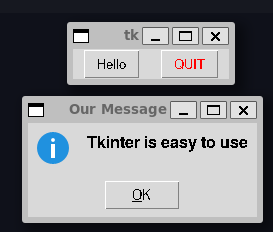
  <figcaption aria-hidden="true">A simple window with two buttons, one of
  which opens a message box</figcaption>
  </figure>

### Importing Fewer Names

- Tkinter is designed to consist of a number of different submodules
- Each submodule is designed to be explicitly loaded to avoid memory
  consumption
  - If we try to use `messagebox` without explicitly importing the
    submodule it won’t load

### Creating an Object-Oriented Version

- In the program above the function to be executed by a button is passed
  to the constructor as a handle
- An Object-Oriented approach, might be to provide a `command` method on
  the `Button` class
  - The `command` method is *overwritten* or *implemented* by subclasses
    of different functionality
- We start by defining the *abstact* base class
  - This is a class that effectively defines *what* our new
    `DerivedButton` classes should look like
  - We provide an `__init__` constructor that acts as a pass through
    constructor for the `tk.Button` base class
    - `**kwargs` in the function signature captures *keyword arguments*
      of the form `key=value` provided in the call
      - These are stored in the variable `kwargs` as a dict
      - These are then unpacked via *back* into `key=value` arguments
        via the `**` unpacking syntax
  - We define an abstract method `command` that is the implementation
    for what `command` is executed when a button is called
    - The `__init__` call links this method to the base-class `Button`
      and it’s `command` interface
- The abstract class is not intended to be instantiated directly

``` python
import tkinter as tk

class DerivedButton(tk.Button):
    def __init__(self, root, **kwargs):
        super().__init__(root, **kwargs)
        super().config(command=self.command)

    # abstract method to by overwritten by children
    def command(self):
        pass
```

- Now we can define our `OKButton` and `QuitButton` as concrete
  subclasses of `DerivedButton`
  - These should be directly instantiated

``` python
from tkinter import messagebox

class OKButton(DerivedButton):
    def __init__(self, root):
        super().__init__(root, text="OK")

    def command(self):
        messagebox.showinfo("Our Message", "Tkinter is easy to use")

class QuitButton(DerivedButton):
    def __init__(self, root):
        super().__init__(root, text="Quit", fg="red")

    def command(self):
        quit()
```

- Here the base class `Button` is hooked into the `DerivedButton`
  `command` method by the `DerivedButton` base class
  - Now when we create an `OKButton` and `QuitButton` we redefine the
    `command` function for those specific classes
  - Now when we click the button the redefined `command` method is
    invoked
- This an example of *polymorphism*
- Building the UI is then pretty simple since the classes mostly handle
  constructing themselves
- The complete code can be found in
  [02-derived-button.py](Examples/02-derived-button/02-derived-button.py)

``` python
def buildUI():
    root = tk.Tk()
    root.geometry("300x100+300+300")

    slogan = OKButton(root)
    slogan.pack(side=tk.LEFT, padx=10)

    button = QuitButton(root)
    button.pack(side=tk.RIGHT, padx=10)

    root.mainloop()
```

- You could also put the `pack` methods inside the classes
  - Potentially as an `__init__` parameter

### Using Message Boxes

- As discussed the message box creates a dialog window that must be
  acknowledged
- There are different ways of calling the message box which modifies how
  it is displayed
- The code below creates a simple window with three buttons which can
  each call a different message box
  - We’ve already seen `showinfo`

  - `showwarning` styles the message as a warning

    <figure>
    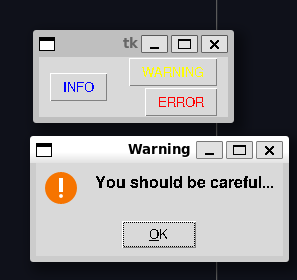
    <figcaption aria-hidden="true">A warning box, on Ubuntu this contains an
    orange exclamation mark</figcaption>
    </figure>

  - `showerror` styles the message as an error

    <figure>
    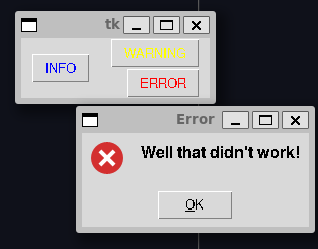
    <figcaption aria-hidden="true">An error box, on Ubuntu this contains a
    red cross symbol</figcaption>
    </figure>

``` python
import tkinter as tk
import tkinter.messagebox

# Set up the window
root = tk.Tk()


# Write a slogan out to a message box
def display_info():

    tk.messagebox.showinfo("Info", "Consider yourself informed")


def display_warning():
    tk.messagebox.showwarning("Warning", "You should be careful...")


def display_error():
    tk.messagebox.showerror("Error", "Well that didn't work!")


info_button = tk.Button(root, text="INFO", fg="Blue", command=display_info)
info_button.pack(side=tk.LEFT, padx=10)

warning_button = tk.Button(root, text="WARNING", fg="Yellow", command=display_warning)
warning_button.pack(padx=10)

error_button = tk.Button(root, text="ERROR", fg="red", command=display_error)
error_button.pack(side=tk.RIGHT, padx=10)

root.mainloop()
```

- The code is contained in
  [03-messagebox.py](Examples/03-messagebox/03-messagebox.py)

- Note that `tk` uses the native windowing system of the Operating
  System it runs on

  - This means that `tk` may look different on your program

- The message box also provides dialogs for standard prompts to the user

  - `askquestion` for asking a question

    <figure>
    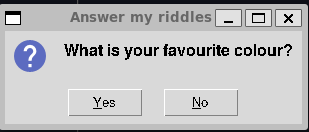
    <figcaption aria-hidden="true">The <code>askquestion</code> dialog looks
    shows a question mark with <em>yes</em> and <em>no</em>
    buttons</figcaption>
    </figure>

  - `askyesno` for asking a yes or no question

    <figure>
    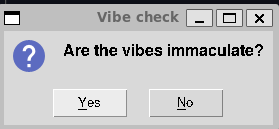
    <figcaption aria-hidden="true">The <code>askyesno</code> dialog looks
    identical to the <code>askquestion</code> dialog on Ubuntu</figcaption>
    </figure>

  - `askyesnocancel` for asking a yes or no question with the option to
    cancel

    <figure>
    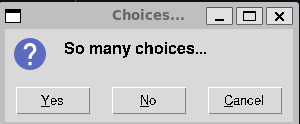
    <figcaption aria-hidden="true">The <code>askyesnocancel</code> dialog
    looks like the <code>askyesno</code> but has an additional
    <em>cancel</em> button</figcaption>
    </figure>

  - `askokcancel` for asking for approval

    <figure>
    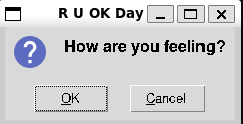
    <figcaption aria-hidden="true">The <code>askokcancel</code> shows a
    question mark with <em>ok</em> and <em>cancel</em> buttons</figcaption>
    </figure>

  - `askretrycancel` for asking to retry an operation

    <figure>
    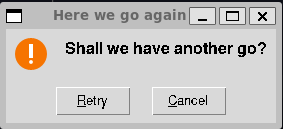
    <figcaption aria-hidden="true">The <code>askretrycancel</code> looks
    like <code>askokcancel</code> but has a warning exclamation mark rather
    than a question mark</figcaption>
    </figure>

- Again we have a program that contains buttons that let’s you look at
  all these dialogs (See
  [04-questioning-message-box.py](Examples/04-questioning-messagebox/04-questioning-message-box.py))

``` python
import tkinter as tk
import tkinter.messagebox


# Write a slogan out to a message box
def ask_ok():
    tk.messagebox.askokcancel("R U OK Day", "How are you feeling?")


def ask_question():
    tk.messagebox.askquestion("Answer my riddles", "What is your favourite colour?")


def ask_retry():
    tk.messagebox.askretrycancel("Here we go again", "Shall we have another go?")


def ask_yesno():
    tk.messagebox.askyesno("Vibe check", "Are the vibes immaculate?")


def ask_yesnocancel():
    tk.messagebox.askyesnocancel("Choices...", "So many choices...")


button_params = [
    (ask_ok, "Ok"),
    (ask_question, "Question"),
    (ask_retry, "Retry"),
    (ask_yesno, "Yes / No"),
    (ask_yesnocancel, "Yes / No / Cancel"),
]

root = tk.Tk()
for cmd, label in button_params:
    but = tk.Button(root, text=label, command=cmd)
    but.pack(padx=10, pady=10)

root.mainloop()
```

### File Dialogs

- Like with message boxes tkinter provides a pre-made dialog for
  selecting files

  - Called `filedialog`

- `filedialog` has a number of methods for interacting with files

- `askopenfilename` opens a dialog for selecting a file by name

  - Has an `ok` and `cancel` button
  - Pressing `ok` returns a sring with the full path of the selected
    file
  - Pressing `cancel` returns an empty string

- Below is an example of a file dialog

  <figure>
  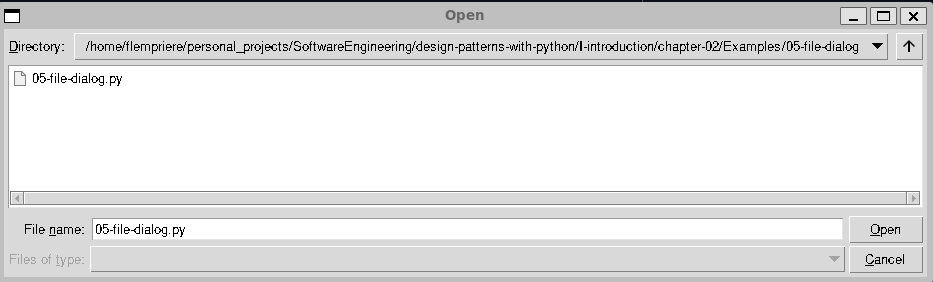
  <figcaption aria-hidden="true">The dialog opened by
  <code>filedialog.askopenfilename</code>. A menu is shown to select files
  from the specified directory along with an <em>ok</em> and
  <em>cancel</em> button. A dropdown menu can be used to narrow the choice
  of file types</figcaption>
  </figure>

  - The full code is in
    [05-file-dialog.py](Examples/05-file-dialog/05-file-dialog.py)

``` python
import tkinter as tk
import tkinter.filedialog

fname = tk.filedialog.askopenfilename()
print(fname)
```

- Other methods on the `filedialog` include,

  - `askdirectory`
    - Asks for a directory and returns the path
  - `askopenfile`
    - Ask for a file to open and return the opened file stream
  - `askopenfilenames` and `askopenfiles` are like the non-plural
    variants but return multiple files
  - `asksaveasfile` and `asksaveasfilename` ask for a filename to save
    as
    - `asksaveasfile` returns the opened file
    - `asksaveasfilename` returns the file name

### The Pack Layout Manager

- `pack` is the most basic tkinter layout manager

- It’s use is generally discouraged in favour of layout managers like
  `grid` but for simple use cases it can be useful to know

- It has a number of layout options

  | Parameter | Description |
  |---------|---------------------------------------------------------------|
  | `fill=tk.X` | Stretch widget to fill frame in the X direction |
  | `fill=tk.Y` | Stretch widget to fill frame in the Y direction |
  | `fill=tk.BOTH` | Stretch widget to fill in both directions |
  | `side=tk.LEFT` | Position widget to left side of the frame |
  | `side=tk.RIGHT` | Position widget to right side of the frame |
  | `expand=n` | Distribute remaining space in the frame among all widgets when `n` is nonzero |
  | `anchor` | Where the widget is placed within the packing box. Options are `tk.CENTER` (default), `tk.N`, `tk.E`, `tk.S`, `tk.W` or combinations e.g `tk.NE` |
  | `padX, padY` | Number of pixels to pad the X and Y dimensions respectively |

- Below is a simple example showing how to put together a simple dialog
  using multiple components laid out with `pack`

  <figure>
  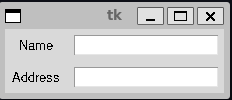
  <figcaption aria-hidden="true">A simple two-row example using the packed
  layout. Each row consists of a <code>tk.Label</code> left-aligned on the
  left, and a <code>tk.Entry</code> on the right stretched to fill the
  remaining space</figcaption>
  </figure>

``` python
import tkinter as tk

root = tk.Tk()

# Create first row, taking up the entire X dimension
first_row = tk.Frame(root)
first_row.pack(fill=tk.X)

# Add widgets to the first row
label_1 = tk.Label(first_row, text="Name", width=7)
label_1.pack(side=tk.LEFT, padx=5, pady=5)

entry_1 = tk.Entry(first_row)
entry_1.pack(fill=tk.X, padx=5, pady=5)  # fill the remaining X space

# Create the second row, again taking the entire X dimension
second_row = tk.Frame(root)
second_row.pack(fill=tk.X)

# Add widgets to the second row
label_2 = tk.Label(second_row, text="Address", width=7)
label_2.pack(side=tk.LEFT, padx=5, pady=5)

entry_2 = tk.Entry(second_row)
entry_2.pack(fill=tk.X, padx=5, pady=5)

root.mainloop()
```

### The `ttk` Library

- Tkinter and the underlying Tk Windowing toolkit is a relatively old
  GUI framework

  - Some of it’s widgets look outdated
  - Also the default set of widgets is missing some common modern-style
    widgets

- Newer versions of Tk often also include a more modern set of widgets
  in the `ttk` library

  - These are kept in a separate library to keep the two different
    widget styles distinct

- `ttk` also modifies how Tk manages state

  - Aims to decouple graphics from the logic of managing the state

- Some of the new widgets in `ttk` includ

  - `Button`
  - `CheckButton`
  - `Entry`
  - `Frame`
  - `Label`
  - `LabelFrame`
  - `MenuButton`
  - `PanedWindow`
  - `RadioButton`
  - `Scale`
  - `Scrollbar`

- To use the new style widgets, simply import and use the appropriate
  `tkinter.ttk` widgets

- For example, using the modernised button we simply replace `tk.Button`
  with `ttk.Button`

  - There is some caveat in that `ttk` uses a different form for styling
  - `foreground` and `background` etc. are no longer part of the
    constructor
  - Instead you register `Style` objects and then invoke them on the
    object

- For example, the new code for the quit button is,

  ``` python
    ttk.Style().configure("W.TButton", foreground="red")
    quit_button = ttk.Button(root, text="QUIT", command=quit, style="W.TButton")
    quit_button.pack(side=tk.RIGHT, padx=10)
  ```

- The full code example is given in
  [07-ttk-button](Examples/07-ttk-button/07-ttk-button.py)

``` python
import tkinter as tk
import tkinter.messagebox
import tkinter.ttk as ttk

# Set up the window
root = tk.Tk()


# Write a slogan out to a message box
def display_slogan():
    tk.messagebox.showinfo("Our Message", "Tkinter is easy to use")


# create a button to call the message
slogan = ttk.Button(root, text="Hello", command=display_slogan)
slogan.pack(side=tk.LEFT, padx=10)

# create a quit button
ttk.Style().configure("W.TButton", foreground="red")
quit_button = ttk.Button(root, text="QUIT", command=quit, style="W.TButton")
quit_button.pack(side=tk.RIGHT, padx=10)

root.mainloop()
```

- The resulting window looks like

  <figure>
  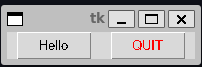
  <figcaption aria-hidden="true">The basic two-button widget updated to
  use the <code>ttk</code> buttons</figcaption>
  </figure>

### Responding to User Input

- Python command-line programs can often read input via the `input`
  function
  - Return’s user supplied strings
- When using graphical-user interfaces, it is often important to have
  widget’s that provide similar functionality
  - The basic version of this in tkinter is the `Entry` widget
  - Provides a simple one-line text entry
- Here is a simple greeter program to demonstrate `Entry`, it accepts a
  name from the user and greets them

``` python
import tkinter as tk


class Greeter:
    def build(self):
        root = tk.Tk()
        tk.Label(
            root,
            text="What is your name?",
            justify=tk.LEFT,
            fg="blue",
            pady=10,
            padx=20,
        ).pack()

        # set up the Entry widget
        self.name_entry = tk.Entry(root)
        self.name_entry.pack()

        # associate button to read the entry
        self.ok_button = tk.Button(root, text="Ok", command=self.get_name)
        self.ok_button.pack()

        # set up greater output
        self.greet_label = tk.Label(root, text="", fg="blue")
        self.greet_label.pack()

        tk.mainloop()

    def get_name(self):
        new_name = self.name_entry.get()
        self.greet_label.configure(text="Hi " + new_name + "!")


if __name__ == "__main__":
    greeter = Greeter()
    greeter.build()
```

- The code can be found in the python script [08-entry.py](08-entry.py).
  It should produce a widget like below

  <figure>
  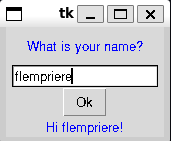
  <figcaption aria-hidden="true">A simple program. A label requests a
  name, and provides an entry box. When the <code>OK</code> button is
  clicked a label appears greeting the provided name</figcaption>
  </figure>

#### Adding Two Numbers

- Often when taking user input, we want to convert it from a `str` to
  some other format
  - A common example is a number
  - As with command-line interfaces, graphical user interfaces should
    generally handle invalid input gracefully too
    - A common use-case for the `messagebox` widget
- For example, here we request two numbers from the user, validate them
  and add them together
  - The program should look like below

    <figure>
    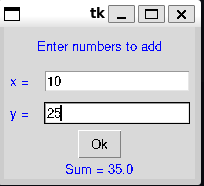
    <figcaption aria-hidden="true">A simple program for adding two
    numbers</figcaption>
    </figure>

  - In the case of an error the program will instead look like below

    <figure>
    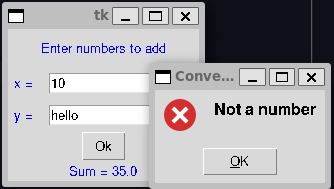
    <figcaption aria-hidden="true">The adder program in case of an
    error</figcaption>
    </figure>
- The code implementation below can be found in
  [09-adder.py](Examples/09-adder/09-adder.py)

``` python
import tkinter as tk
import tkinter.messagebox


class NumberEntry(tk.Frame):
    def __init__(self, master, label):

        super().__init__(master)

        label = tk.Label(self, text=label, width=3, fg="blue")
        label.pack(side=tk.LEFT, padx=5, pady=5)

        self.entry = tk.Entry(self)
        self.entry.pack(fill=tk.X, padx=5, pady=5)

    def get(self):
        return self.entry.get()


class Adder:
    def build(self):
        root = tk.Tk()
        tk.Label(
            root,
            text="Enter numbers to add",
            justify=tk.LEFT,
            fg="blue",
            pady=10,
            padx=20,
        ).pack()

        # Create each row of numbers
        self.x_row = NumberEntry(root, "x = ")
        self.x_row.pack()

        self.y_row = NumberEntry(root, "y = ")
        self.y_row.pack()

        # associate button to read the entry
        self.ok_button = tk.Button(root, text="Ok", command=self.add_numbers)
        self.ok_button.pack()

        # set up output
        self.sum_label = tk.Label(root, text="", fg="blue")
        self.sum_label.pack()

        tk.mainloop()

    def add_numbers(self):
        try:
            x = float(self.x_row.get())
            y = float(self.y_row.get())
            self.sum_label.configure(text="Sum = " + str(x + y))
        except ValueError:
            tk.messagebox.showerror("Conversion Error", "Not a number")


if __name__ == "__main__":
    adder = Adder()
    adder.build()
```

- One fun implementation of the code above is that we define a
  lightweight `NumberEntry` widget
  - This centralises the creation of the row’s for getting a number from
    the user
  - Mean’s we can reuse it for both rows
  - This is a nice case of *Don’t Repeat Yourself*
- We use a `try`, `except` block to catch the error and show the error
  by calling a `tk.messagebox.showerror`

### Applying Colours in Tkinter

- Tkinter provides pre-defined named colour strings

  1.  `"white"`
  2.  `"black"`
  3.  `"red"`
  4.  `"green"`
  5.  `"blue"`
  6.  `"cyan"`
  7.  `"yellow"`
  8.  `"magenta"`

- Alternatively colours can be specified as hexadecimal values

  - Can be

    1.  `#RGB`
    2.  `#RRGGBB`
    3.  12-bit strings
    4.  16-bit strings

- For example,

  - `"red"` = `#f00`
  - Purple = `#c0f`

- Each digit is hexadecimal, i.e. `0` to `F`

- For example, recall the QUIT button we defined using the `ttk` set was
  coloured via,

``` python
ttk.Style().configure("W.TButton", foreground="red")
quit_button = ttk.Button(root, text="QUIT", command=quit, style="W.TButton")
quit_button.pack(side=tk.RIGHT, padx=10)
```

### Radio Buttons

- Radio buttons are named after old analog car radio buttons
  - Selecting one would deselect all other buttons
- Radio buttons are now a common widget style for mutually exclusive
  choices
  - Radio buttons are created *individually*
  - Assigned to a *group*
    - This group is of type `IntVar`
    - `IntVar` is a special tk wrapper around an integer
    - Automatically updates in response to state changes that it is
      listening to
    - Here the state changes are the index corresponding to which radio
      button is selected
  - Only one radio button in each group can be selected
- Radio buttons can either show up as individual circles next to a label
  or traditional style buttons
  - Controlled via the `indicatoron` parameter
  - If using individual circles the selected circle has black dot
    (default)
  - If using traditional style buttons, the selected button is depressed
    (`indicatoron = False`)
- Radio buttons also accept a `command` parameter like the normal button
  - This corresponds to the callback to be called when the button is
    selected
- Here we have a simple program which uses radio buttons to set the
  state of a traffic light
  - The full implementation is in
    [10-radio-buttons.py](Examples/10-radio-buttons/10-radio-buttons.py)
- Our rewrite avoids the derived class implementation of the original
  code example
  - Instead we use a simple functional closure approach
  - I think this is a cleaner architecture

``` python
import tkinter as tk


class TrafficLightModeSelection:
    def build(self):
        root = tk.Tk()

        # set up the heading label
        tk.Label(
            root, text="Choose your favourite colour:", justify=tk.LEFT, padx=20
        ).pack()

        # label to be updated
        current_light_colour = tk.Label(root, text="")

        # set up the radio buttons
        traffic_light_choice = tk.IntVar()
        colours = ["red", "yellow", "green"]

        # closure function to be called
        def update_light_colour():

            colour_idx = traffic_light_choice.get()
            colour = colours[colour_idx]

            current_light_colour.configure(
                fg=colour,
                text=f"The light is {colour}",
            )

        buttons = [
            tk.Radiobutton(
                root,
                text=colour,
                padx=20,
                command=update_light_colour,
                variable=traffic_light_choice,
                value=i,
            )
            for i, colour in enumerate(colours)
        ]

        # set up the layout

        for button in buttons:
            button.pack()

        current_light_colour.pack()

        tk.mainloop()


if __name__ == "__main__":
    traffic_light_controller = TrafficLightModeSelection()
    traffic_light_controller.build()
```

- The program above should look like the following when run

  <figure>
  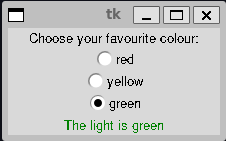
  <figcaption aria-hidden="true">A simple radio button group consisting of
  the traffic light states, <em>green</em>, <em>yellow</em> and
  <em>red</em>. A label is automatically updated when the choice is
  changed</figcaption>
  </figure>

- If we instead use `indicatoron = False`

  <figure>
  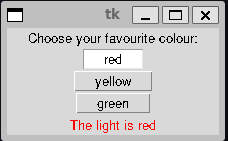
  <figcaption aria-hidden="true">In this version of the application, the
  radio butttons are displayed as normal buttons, with the selected button
  depressed</figcaption>
  </figure>

#### Using Class Variables

- Here we have three button’s all referencing the *same* variable to
  track their group
- A potential design is to derive a class from `RadioButton` for this
  specific group and store this group variable as a class variable
  - This keeps all the information about the specific radio button group
    together in the one place
  - Here the class definition
- Since it is defined at the class-level one variable instance is shared
  between all class instances
- The new program
  [11-radio-buttons-with-class-variable.py](Examples/11-radio-buttons-with-class-variable/11-radio-buttons-with-class-variable.py)
  is styled much more like the original implementation
  - However rather than use a `main` function to define everything we’ve
    used the `build` method paradigm used in previous examples

``` python
import tkinter as tk
from typing import Literal


class ColourButton(tk.Radiobutton):
    # define the group variable
    # We have to wait until we create a root window before we can set it
    group: tk.IntVar | Literal[""] = ""

    def __init__(self, master, colour, index, colour_label):
        super().__init__(
            master,
            text=colour,
            padx=20,
            command=self.clicked,
            variable=ColourButton.group,
            value=index,
        )

        self.pack(anchor=tk.W)
        self.colour = colour
        self.colour_label = colour_label
        self.index = index

    def clicked(self):
        self.colour_label.configure(fg=self.colour, text=f"The light is {self.colour}")


class TrafficLightModeSelection:
    def build(self):
        root = tk.Tk()

        # set up the heading label
        tk.Label(
            root, text="Choose your favourite colour:", justify=tk.LEFT, padx=20
        ).pack()

        # set up the output label
        colour_label = tk.Label(root, text="")

        # set up radio buttons
        ColourButton.group = tk.IntVar()
        colours = ["red", "yellow", "green"]
        for idx, colour in enumerate(colours):
            ColourButton(root, colour, idx, colour_label=colour_label)

        colour_label.pack()
        root.mainloop()


if __name__ == "__main__":
    traffic_light_selection = TrafficLightModeSelection()
    traffic_light_selection.build()
```

> **Note**
>
> **Classes and Class Variables**
>
> The class-based design and the use of class variables is a game of
> trade-offs. Here we see it helps centralise all the information for
> our traffic light choice group in one location. However, the caveat is
> that now *any* instance of a `ColourButton` *must* be associated with
> the same group. A natural future case might be that we want to reuse
> the `ColourButton` in a different context. At this point the group
> variable would have to be moved back out of the class scope.
>
> This is a *design decision*. There is no right answer. It depends on
> your code. In general though I prefer fewer, reusable classes and a
> functional approach.

### Communicating Between Classes

- Creating individual self-contained widgets is pretty straightforward
- How do we manage communicating betwen widgets that are not
  self-contained?
  - For example, how does a different part of the program respond to a
    choice from our `ColourButton`?
- The correct way to set-up communications in a program is an open
  discussion
  - One common pattern here that will be discussed later is the Mediator
    Pattern

### Using the Grid Layout

- The grid layout manager is the more modern and preferred layout
  manager over pack
- Allows widgets to be arranged by placing them at select rows and
  columns
  - No limit on what are valid row and column numbers (as long as they
    are non-negative)
  - Layout determined once set
  - Don’t need to declare the number of rows or columns upfront
- For example, we can replicate our [pack](#the-pack-layout-manager)
  layout example but with a grid

``` python
import tkinter as tk

root = tk.Tk()
root.title("grid")

# Add widgets to the first row
label_1 = tk.Label(root, text="Name", sticky=tk.W)
label_1.grid(row=0, column=0, padx=5, pady=5)

entry_1 = tk.Entry(root)
entry_1.grid(row=0, column=1)

# Add widgets to the second row
label_2 = tk.Label(root, text="Address")
label_2.grid(row=1, column=0, padx=5, pady=5, sticky=tk.W)

entry_2 = tk.Entry(root)
entry_2.grid(row=1, column=1, padx=5)

root.mainloop()
```

- We can see this implementation is much simpler than `pack` where we
  had to introduced `Frame` objects for each row and ensure the pack
  ordering and parameters were correct for every object
- By default widgets are aligned to the center of the grid
  - This can look odd especially for layered text labels since they
    won’t b aligned
- `grid` provides the `sticky` parameter which can be used to *stick* a
  widget to a given side of the grid cell
  - The sticky values are
    1.  `tk.N`
    2.  `tk.E`
    3.  `tk.S`
    4.  `tk.W`
    5.  Combinations of the above like `tk.N + tk.E`

### Checkbuttons

- We’ve seen that we can create [Radio Buttons](#radio-buttons) which
  allow for selecting mutually exclusive options from a set

- Checkboxes or Checkbuttons are the equivalent when we want a user to
  be able to select multiple options from a group

- For example, let’s create a widget for selecting pizza toppings

  - The final product should look like,

    <figure>
    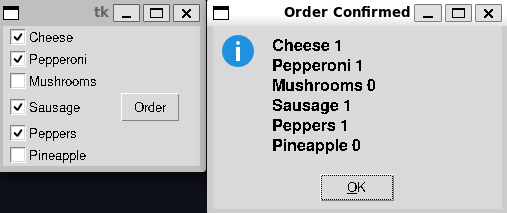
    <figcaption aria-hidden="true">A simple checkbox list of pizza toppings
    and a button to order. Once ordered a confirmation dialog is
    shown</figcaption>
    </figure>

- For checkboxes, since each can be toggled individually, rather than
  having *one* variable `IntVar` shared among all the radio buttons,
  each one has their own.

- Our `CheckBox` class is derived from the `tk.CheckButton` class

  ``` python
    class CheckBox(tk.Checkbutton):
        def __init__(self, root, text, group):
            super().__init__(root, text=text, variable=group)

            self.text = text
            self.group = group

        def get_state(self):
            return self.group.get()
  ```

- We’ll also define our `OKButton` class which confirms the order and
  displays the summary

  - This needs to receive the list of checkboxes which it listens to

  ``` python
    class OKButton(tk.Button):
        def __init__(self, root, boxes):
            super().__init__(root, text="Order", command=self.clicked)

            self.boxes = boxes

        def clicked(self):

            order = "\n".join([f"{box.text} {box.get_state()}" for box in self.boxes])
            tk.messagebox.showinfo(title="Order Confirmed", message=order)
  ```

- We can the finally put everything together. We use a simple list
  construct to generate the buttons we need from the list of available
  toppings

``` python
   class PizzaToppingsSelection:
       def build(self):

           root = tk.Tk()

           names = ["Cheese", "Pepperoni", "Mushrooms", "Sausage", "Peppers", "Pineapple"]
           boxes = [CheckBox(root, name, tk.IntVar()) for name in names]
           for idx, box in enumerate(boxes):
               box.grid(column=0, row=idx, sticky=tk.W)

           OKButton(root, boxes).grid(column=1, row=3, padx=20)

           tk.mainloop()
```

- The complete program can be found in
  [13-check-buttons.py](Examples/13-check-buttons/13-check-buttons.py)

#### Disabling Check Boxes

- Sometime’s certain checkboxes want to be disabled

  - E.g. For example there might be incompatible choices
  - Or some other part of your program defines what checkboxes are
    allowed

- The can be done by setting the `state` parameter of a checkbox to
  `tk.DISABLED`

  - To turn the button back on use set the state back to `tk.NORMAL`

- For example, to disable pineapple on pizza in the above example, we
  can modify the `__init__` of the `CheckBox` class as follows

  ``` python
    class CheckBox(tk.Checkbutton):
        def __init__(self, root, text, group):
            super().__init__(root, text=text, variable=group)

            self.text = text
            self.group = group

            if self.text.lower() == "pineapple":
                self.configure(state=tk.DISABLED)

        def get_state(self):
            return self.group.get()
  ```

### Adding Menus to Windows

- Consider the following basic menu layout

  | **File** | **Draw** |
  |----------|----------|
  | New      | Circle   |
  | Open     | Square   |
  | Exit     |          |

- This is straightforward to implement through `tkinter`

- The code below should create a program that looks like,

  <figure>
  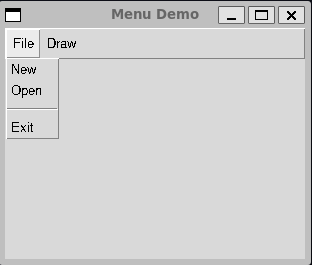
  <figcaption aria-hidden="true">A simple window with two
  menus</figcaption>
  </figure>

- The code below (see [15-menus.py](Examples/15-menus/15-menus.py))
  shows how to create the menus

``` python
import tkinter as tk


def build_menu(root):

    root.title("Menu Demo")
    root.geometry("300x200")

    menu_bar = tk.Menu(root)
    root.config(menu=menu_bar)

    file_menu = tk.Menu(menu_bar, tearoff=False)
    menu_bar.add_cascade(label="File", menu=file_menu)

    file_menu.add_command(label="New")
    file_menu.add_command(label="Open")
    file_menu.add_separator()
    file_menu.add_command(label="Exit")

    draw_menu = tk.Menu(menu_bar, tearoff=False)
    menu_bar.add_cascade(label="Draw", menu=draw_menu)
    draw_menu.add_command(label="Circle")
    draw_menu.add_command(label="Square")


def main():
    root = tk.Tk()
    build_menu(root)
    tk.mainloop()


if __name__ == "__main__":
    main()
```

- Here we’ve skipped the implementation of actually wiring up the menu
  elements to specific commands or functions

  - To avoid polluting the main levels of the program with functions for
    the menu’s we might want to consider encapsulating them in classes
    - One structure is each class handles one menu command
    - This works similar to the structure of the `Button` class

- One structure is,

  1.  A `MenuBar` class for holding the menus
  2.  A `TopMenu` that holds the name of a menu
      - Needs a mechanism to add menu commands
  3.  Create a `MenuCommand` class for each menu item
      - Start by defining a `MenuCommand` base class

- We can implement these basic classes as below

  ``` python
    class MenuBar(tk.Menu):
        def __init__(self, root):
            super().__init__(root)
            root.config(menu=self)


    class TopMenu:
        def __init__(self, root, label, menu_bar):

            self.menu_bar = menu_bar
            self.root = root
            self.menu = tk.Menu()

            self.menu_bar.add_cascade(label=label, menu=self.menu)

        def add_menu_item(self, menu_item):
            self.menu.add_command(label=menu_item.get_label(), command=menu_item.command)

        def add_separator(self):
            self.menu.add_separator()


    # Abstract base class for menu's
    class MenuCommand:
        def __init__(self, root, label):
            self.root = root
            self.label = label

        def get_label(self):
            return self.label

        def command(self):
            pass
  ```

- We then want to implement the specific classes for each menu item

  - Here are our basic `MenuCommand` classes for each of the file menu
    options

    - `QuitCommand` calls `sys.exit` to close the progam
    - `NewCommand` wipes the current program’s title
    - `OpenCommand` set the title to the selected file
      - After stripping the leading path factors

    ``` python
        class QuitCommand(MenuCommand):
            def command(self):
                sys.exit()


        class NewCommand(MenuCommand):
            def command(self):
                self.root.title("")


        class OpenCommand(MenuCommand):
            def command(self):

                file_path = tk.filedialog.askopenfilename(title="Select File")
                if len(file_path.strip()) > 0:
                    path_components = file_path.split("/")
                    if len(path_components):
                        file_name = path_components[-1]
                        self.root.title(file_name)
    ```

  - Next we want to add the commands for our `Draw` menu

    ``` python
        class DrawCircle(MenuCommand):
            def __init__(self, root, canvas, label):
                super().__init__(root, label)
                self.canvas = canvas

            def command(self):
                self.canvas.create_oval(130, 40, 200, 110, fill="red")


        class DrawSquare(MenuCommand):
            def __init__(self, root, canvas, label):
                super().__init__(root, label)
                self.canvas = canvas

            def command(self):
                self.canvas.create_rectangle(10, 80, 110, 180, fill="blue")
    ```

- Lastly we update our `build_menu` function to use the new classes

  ``` python
    def build_menu(root):

    root.title("Menu Demo")
    root.geometry("300x200")
    canvas = tk.Canvas(root)
    canvas.pack()

    menu_bar = MenuBar(root)

    file_menu = TopMenu(root, "File", menu_bar)
    file_menu.add_menu_item(NewCommand(root, "New"))
    file_menu.add_menu_item(OpenCommand(root, "Open"))
    file_menu.add_separator()
    file_menu.add_menu_item(QuitCommand(root, "Quit"))

    draw_menu = TopMenu(root, "Draw", menu_bar)
    draw_menu.add_menu_item(DrawCircle(root, canvas, "Circle"))
    draw_menu.add_menu_item(DrawSquare(root, canvas, "Square"))
  ```

- The complete code can be found in
  [16-menu-class.py](Examples/16-menu-class/16-menu-class.py)

### Label Frame

- The last widget we’ll look at in this section is the `LabelFrame`

  - This acts like a `Frame` widget
    - A container for other widges
  - But can have a label integrated into the frame

  <figure>
  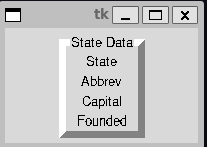
  <figcaption aria-hidden="true">A simple example of a label frame to
  denote a set of State Data</figcaption>
  </figure>

- The code to create the label above is given in
  [17-label-frame.py](Examples/17-label-frame/17-label-frame.py) and
  replicated below

  ``` python
    import tkinter as tk


    def build_ui():
        root = tk.Tk()
        root.geometry("100x150")

        label_frame = tk.LabelFrame(
            root, text="State Data", borderwidth=7, relief=tk.RAISED
        )
        label_frame.pack(pady=5)

        tk.Label(label_frame, text="State").pack()
        tk.Label(label_frame, text="Abbrev").pack()
        tk.Label(label_frame, text="Capital").pack()
        tk.Label(label_frame, text="Founded").pack()

        tk.mainloop()


    if __name__ == "__main__":
        build_ui()
  ```

## Summary

- This chapter demonstrates most of the basic widget functionality in
  tkinter
- The next chapter will look at techniques for displaying data